<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/week1-and-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |


In [ ]:
#USE ONLY THE UNITS SPECIFIED IN THE COMMENTS AFTER EACH VALUE IN THIS CELL

Ms_in = 380e3            # [A/m]
K_in = 315e3               # [J/m^3]
Cp_in = 650                # [J/(kg K)]
rho_in = 5280              # [kg/m^3]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===========INPUT===========

In [ ]:
def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

kB_in = 1.380649e-23        # [J/K] ค่าคงที่
mu0_in = 4 * np.pi * 1e-7   # [H/m]
tau0_in = 1e-9              # [s]

H_app_in = 0.1e-3             # [Tesla]
eta_in = 0.0015             # [Pa s]
T_in = 300                   # [K] 300
f_in = 300e3              # [Hz] แก้ให้เป็น 300kHz
delta_in = 0.1e-9           # [m] ส่วนพื้นผิว 10 nm
R_in = [0.2e-9, .2e-9, 8e-9]              # [m] [0.2e-9, .2e-9, 8e-9]

kB = get_val(kB_in)
mu0 = get_val(mu0_in)
tau0 = get_val(tau0_in)
rho = get_val(rho_in)
Cp = get_val(Cp_in)
Ms = get_val(Ms_in)
K = get_val(K_in)
eta = get_val(eta_in)
T = get_val(T_in)
f = get_val(f_in)
delta = get_val(delta_in)
R = get_val(R_in)

H_app = get_val(H_app_in) / mu0                  # tesla เป็น [A/m]
omega = 2 * np.pi * f                        # [rad/s]

In [ ]:
VM = (4/3) * np.pi * (R**3)
VH = VM * ((1 + (delta / R))**3)
print(f"VM: {VM}")
print(f"VH: {VH}")

VM: [3.35103216e-29 2.68082573e-28 9.04778684e-28 2.14466058e-27
 4.18879020e-27 7.23822947e-27 1.14940403e-26 1.71572847e-26
 2.44290245e-26 3.35103216e-26 4.46022381e-26 5.79058358e-26
 7.36221766e-26 9.19523226e-26 1.13097336e-25 1.37258277e-25
 1.64636210e-25 1.95432196e-25 2.29847296e-25 2.68082573e-25
 3.10339089e-25 3.56817905e-25 4.07720083e-25 4.63246686e-25
 5.23598776e-25 5.88977413e-25 6.59583661e-25 7.35618581e-25
 8.17283234e-25 9.04778684e-25 9.98305992e-25 1.09806622e-24
 1.20426043e-24 1.31708968e-24 1.43675504e-24 1.56345757e-24
 1.69739832e-24 1.83877837e-24 1.98779877e-24 2.14466058e-24]
VH: [1.13097336e-28 5.23598776e-28 1.43675504e-27 3.05362806e-27
 5.57527976e-27 9.20277208e-27 1.41371669e-26 2.05795263e-26
 2.87309120e-26 3.87923861e-26 5.09650104e-26 6.54498469e-26
 8.24479576e-26 1.02160404e-25 1.24788249e-25 1.50532554e-25
 1.79594380e-25 2.12174790e-25 2.48474846e-25 2.88695610e-25
 3.33038143e-25 3.81703507e-25 4.34892765e-25 4.92806979e-25
 5.55647209e-25

In [ ]:
# Calculate xi (ξ) using the formula: μ₀MsVH₀/(k_BT)
# H_app is already in A/m
xi = (mu0 * Ms * VH * H_app) / (kB * T)

if isinstance(xi, np.ndarray) and xi.size > 1:
    print(f"Calculated xi (ξ) range: [{xi.min():.2e}, {xi.max():.2e}]")
else:
    print(f"Calculated xi (ξ): {xi:.2e}")

# Check if all xi values are less than or equal to 1
if np.all(xi <= 1):
    print("All values of xi are <= 1")
else:
    print("!!!!!!!!!!!Not all values of xi are <= 1!!!!!!!!!!!!!!!!!!!")

Calculated xi (ξ) range: [1.04e-06, 2.04e-02]
All values of xi are <= 1


# ===========TAU===========

In [ ]:
# ===========TAU BROWNIAN CALCULATION===========
tau_b = (3 * eta * VH) / (kB * T)
print(f"tau_b: {tau_b}")
# ===========GAMMA CALCULATION===========
gamma = (K * VM) / (kB * T)
# ===========TAU NEEL CALCULATION===========
tau_n = (tau0/2) * np.exp(gamma)
print(f"tau_n: {tau_n}")

tau_b: [1.22874100e-10 5.68861574e-10 1.56095616e-09 3.31760070e-09
 6.05723804e-09 9.99831103e-09 1.53592625e-08 2.23585353e-08
 3.12145723e-08 4.21458163e-08 5.53707102e-08 7.11076968e-08
 8.95752189e-08 1.10991719e-07 1.35575641e-07 1.63545427e-07
 1.95119520e-07 2.30516362e-07 2.69954398e-07 3.13652068e-07
 3.61827817e-07 4.14700088e-07 4.72487322e-07 5.35407963e-07
 6.03680453e-07 6.77523237e-07 7.57154755e-07 8.42793452e-07
 9.34657770e-07 1.03296615e-06 1.13793704e-06 1.24978888e-06
 1.36874011e-06 1.49500917e-06 1.62881452e-06 1.77037458e-06
 1.91990781e-06 2.07763265e-06 2.24376753e-06 2.41853091e-06]
tau_n: [5.01275875e-10 5.10298627e-10 5.35616058e-10 5.88579548e-10
 6.87574770e-10 8.67039094e-10 1.19840112e-09 1.84353467e-09
 3.20499077e-09 6.39395282e-09 1.48634640e-08 4.08808020e-08
 1.35085376e-07 5.44537284e-07 2.71905540e-06 1.70773485e-05
 1.36985806e-04 1.42503076e-03 1.95212330e-02 3.57573551e-01
 8.89281912e+00 3.04909010e+02 1.46351973e+04 9.98539445e+05
 9.833564

In [ ]:
# ===========EFFECTIVE RELAXATION TIME CALCULATION===========
tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))
print(f"tau_eff: {tau_eff}")

tau_eff: [9.86843298e-11 2.68995539e-10 3.98781009e-10 4.99892938e-10
 6.17482526e-10 7.97850638e-10 1.11166393e-09 1.70310783e-09
 2.90655683e-09 5.55170257e-09 1.17179502e-08 2.59574841e-08
 5.38603672e-08 9.21990166e-08 1.29136716e-07 1.61994051e-07
 1.94841991e-07 2.30479080e-07 2.69950665e-07 3.13651793e-07
 3.61827803e-07 4.14700087e-07 4.72487322e-07 5.35407963e-07
 6.03680453e-07 6.77523237e-07 7.57154755e-07 8.42793452e-07
 9.34657770e-07 1.03296615e-06 1.13793704e-06 1.24978888e-06
 1.36874011e-06 1.49500917e-06 1.62881452e-06 1.77037458e-06
 1.91990781e-06 2.07763265e-06 2.24376753e-06 2.41853091e-06]


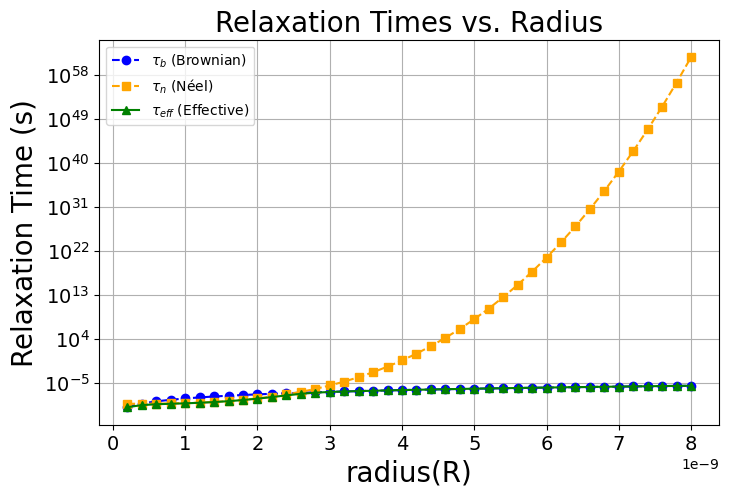

In [ ]:
import matplotlib.pyplot as plt

# =========== PLOT RELAXATION TIMES VS Radius ===========

plt.figure(figsize=(8, 5))

plt.plot(R, tau_b, label=r'$\tau_b$ (Brownian)', linestyle='--', marker='o', color='blue')
plt.plot(R, tau_n, label=r'$\tau_n$ (Néel)', linestyle='--', marker='s', color='orange')
plt.plot(R, tau_eff, label=r'$\tau_{eff}$ (Effective)', linestyle='-', marker='^', color='green')

plt.xlabel('radius(R)', fontsize=20)
plt.ylabel('Relaxation Time (s)', fontsize=20)
plt.title('Relaxation Times vs. Radius', fontsize=20)
plt.yscale('log') # ใช้ log scale
plt.legend()
plt.grid(True)
plt.tick_params(axis='both', labelsize=14)
plt.show()

# ===========SUSCEPTIBILITBY===========

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

chi0 = (mu0 * (Ms ** 2) * VM) / (3 * kB * T)
chi_prime = chi0 / (1 + (omega * tau_eff) ** 2)
chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)

print(f"chi0 : {chi0}")
print(f"chi_prime : {chi_prime}")
print(f"chi_doubleprime : {chi_doubleprime}")


chi0 : [4.89361571e-04 3.91489257e-03 1.32127624e-02 3.13191405e-02
 6.11701963e-02 1.05702099e-01 1.67851019e-01 2.50553124e-01
 3.56744585e-01 4.89361571e-01 6.51340251e-01 8.45616794e-01
 1.07512737e+00 1.34280815e+00 1.65159530e+00 2.00442499e+00
 2.40423340e+00 2.85395668e+00 3.35653101e+00 3.91489257e+00
 4.53197751e+00 5.21072200e+00 5.95406223e+00 6.76493435e+00
 7.64627454e+00 8.60101897e+00 9.63210380e+00 1.07424652e+01
 1.19350393e+01 1.32127624e+01 1.45785706e+01 1.60353999e+01
 1.75861868e+01 1.92338672e+01 2.09813773e+01 2.28316534e+01
 2.47876316e+01 2.68522481e+01 2.90284390e+01 3.13191405e+01]
chi_prime : [4.89361554e-04 3.91489156e-03 1.32127549e-02 3.13191127e-02
 6.11701135e-02 1.05701860e-01 1.67850282e-01 2.50550542e-01
 3.56733877e-01 4.89307986e-01 6.51022635e-01 8.43597207e-01
 1.06415887e+00 1.30343992e+00 1.55920931e+00 1.83347274e+00
 2.11847981e+00 2.40082382e+00 2.66619193e+00 2.90090730e+00
 3.09315370e+00 3.23438158e+00 3.32035639e+00 3.35142381e+00
 3.3

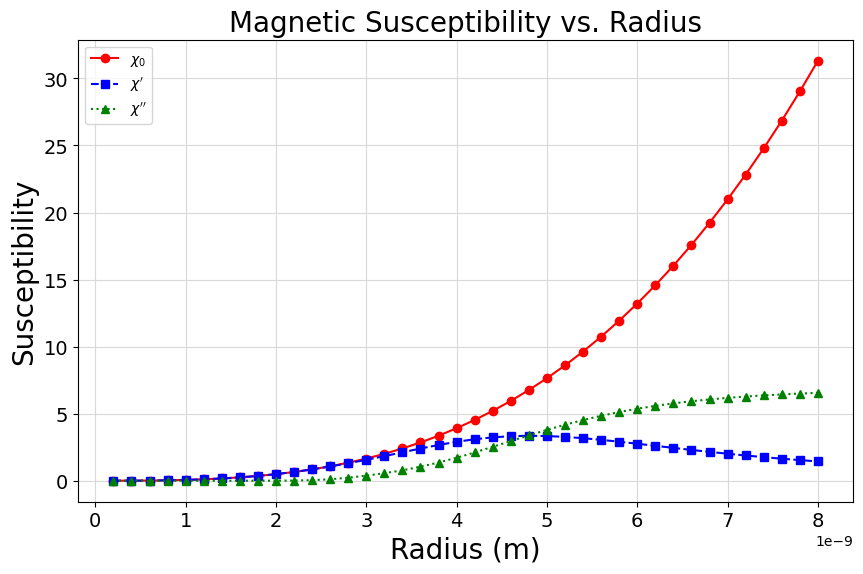

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(R, chi0, label=r'$\chi_0$', marker='o', linestyle='-', color='red')
plt.plot(R, chi_prime, label=r"$\chi'$", marker='s', linestyle='--', color='blue')
plt.plot(R, chi_doubleprime, label=r"$\chi''$", marker='^', linestyle=':', color='green')

plt.xlabel('Radius (m)', fontsize=20)
plt.ylabel('Susceptibility', fontsize=20)
plt.title('Magnetic Susceptibility vs. Radius', fontsize=20)
plt.legend(loc='upper left')
plt.grid(True, which="both", ls="-", color='0.85')
plt.tick_params(axis='both', labelsize=14)
plt.show()

# ===========POWER DISSIPATION===========

---



In [ ]:
#POWER DISSIPATION
P = mu0 * H_app ** 2 * f * np.pi * chi_doubleprime
print(f"Power dissiption: {P}")
#Heating rate
T_s = P / (rho * Cp)
print(f"Heating rate: {T_s}")
SAR = P / rho   # [W/m³] / [kg/m³] = [W/kg]
print(f"SAR: {SAR} W/kg")

Power dissiption: [6.82716547e-04 1.48876860e-02 7.44886725e-02 2.21334359e-01
 5.33981664e-01 1.19224803e+00 2.63789786e+00 6.03253540e+00
 1.46583659e+01 3.84035066e+01 1.07847511e+02 3.09570890e+02
 8.10285682e+02 1.69894647e+03 2.84653510e+03 4.19890366e+03
 5.83538178e+03 7.82265521e+03 1.01750886e+04 1.28630516e+04
 1.58221618e+04 1.89621583e+04 2.21787593e+04 2.53674354e+04
 2.84358863e+04 3.13124969e+04 3.39497409e+04 3.63231648e+04
 3.84275122e+04 4.02716661e+04 4.18736767e+04 4.32565923e+04
 4.44453422e+04 4.54646286e+04 4.63376443e+04 4.70854005e+04
 4.77264684e+04 4.82769805e+04 4.87507805e+04 4.91596470e+04]
Heating rate: [1.98926733e-10 4.33790386e-09 2.17041587e-08 6.44913635e-08
 1.55589063e-07 3.47391617e-07 7.68618256e-07 1.75773176e-06
 4.27108565e-06 1.11898329e-05 3.14240998e-05 9.02013083e-05
 2.36097227e-04 4.95031022e-04 8.29409995e-04 1.22345678e-03
 1.70028607e-03 2.27932844e-03 2.96476939e-03 3.74797541e-03
 4.61018701e-03 5.52510440e-03 6.46234245e-03 7.3914

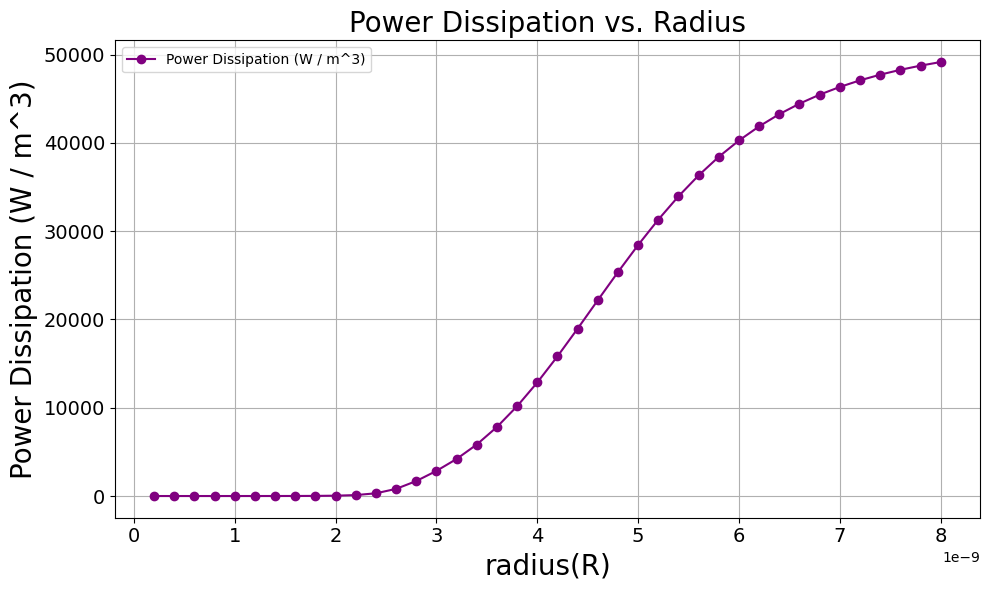

In [ ]:
# Plot Power Dissipation
plt.figure(figsize=(10, 6))
plt.plot(R, P, marker='o', linestyle='-', color='purple', label='Power Dissipation (W / m^3)')
plt.ylabel('Power Dissipation (W / m^3)', fontsize=20)
plt.title('Power Dissipation vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left')
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('radius(R)', fontsize=20)
plt.tight_layout()
plt.show()

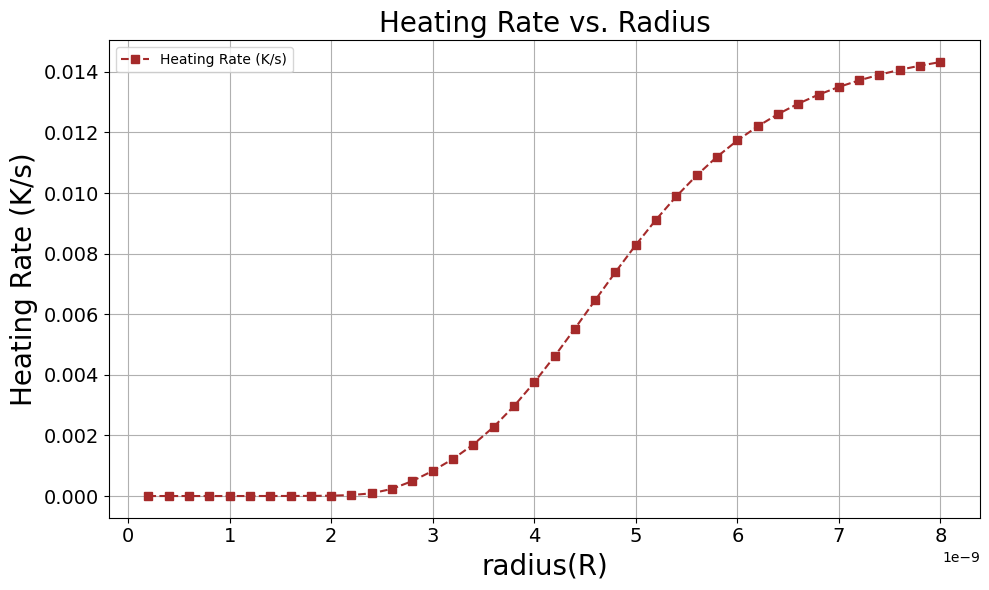

In [ ]:
# Plot Heating Rate
plt.figure(figsize=(10, 6))
plt.plot(R, T_s, marker='s', linestyle='--', color='brown', label='Heating Rate (K/s)')
plt.ylabel('Heating Rate (K/s)', fontsize=20)
plt.title('Heating Rate vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left')
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('radius(R)', fontsize=20)
plt.tight_layout()
plt.show()

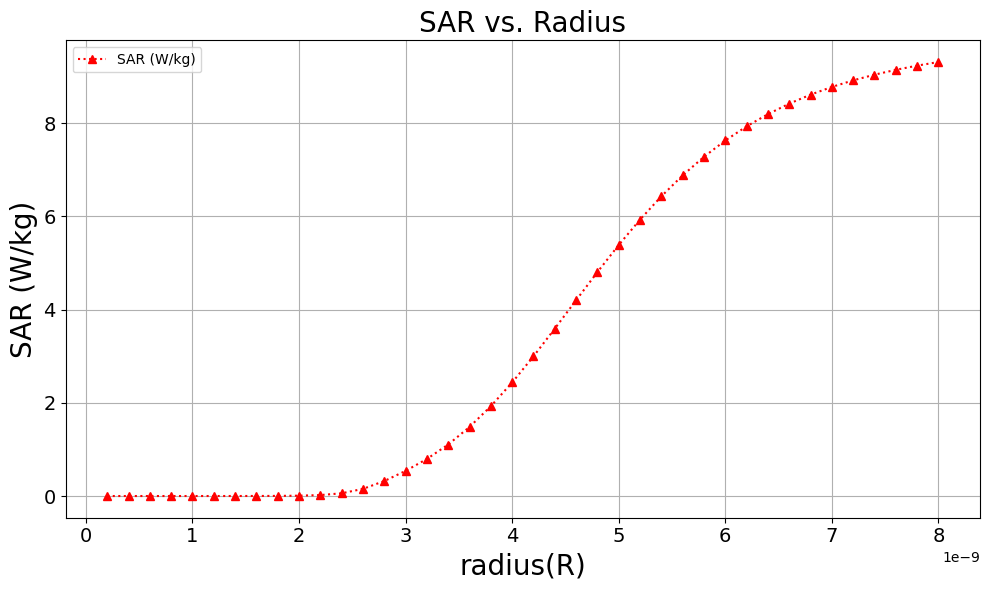

In [ ]:
# Plot SAR
plt.figure(figsize=(10, 6))
plt.plot(R, SAR, marker='^', linestyle=':', color='red', label='SAR (W/kg)')
plt.xlabel('radius(R)', fontsize=20)
plt.ylabel('SAR (W/kg)', fontsize=20)
plt.title('SAR vs. Radius', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left')
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()

==================================================================
 Nanoparticle Temperature vs Time (Magnetic Hyperthermia, LRT)
==================================================================

Validity check: LRT applies when xi = (mu0 * Ms * V_H * H0) / (kB * T) <= 1

HOW IT WORKS
------------
Fixed inputs: viscosity (eta), frequency (f), core radius (R),
              shell thickness (delta)

Field: H(t) amplitude is defined as a function of time

Procedure:
  1. Set initial temperature T_initial
  2. Loop over each time step (n_steps = t_total / dt):
       - compute H(t)
       - compute relaxation times (tau_B, tau_N, tau_eff)
       - compute chi0 and chi'' (out-of-phase susceptibility)
       - compute power dissipation P
       - compute heating rate and update temperature
       - store H(t), heating rate, temperature, and xi
  3. Stop if xi >= 1 (outside the linear response regime)


In [ ]:
dt        = 1e-2      # [s]  time step
t_total   = 200       # [s]  เวลารวม
n_steps   = int(t_total / dt)
T_initial = 300.0     # [K]

# ================================================================
# ================================================================
eta   = 0.0015        # [Pa s]
f     = 300e3         # [Hz]
delta = 1e-9          # [m]
R     = 6e-9          # [m]

omega = 2 * np.pi * f
VM = (4.0 / 3.0) * np.pi * R ** 3
VH = (4.0 / 3.0) * np.pi * (R + delta) ** 3

# ================================================================
#  H_A(t) : amplitude ของสนาม [Tesla] เป็นฟังก์ชันของเวลา
#  >>> แก้สูตรตรงนี้ทีเดียว <<<
# ================================================================
H_max = 1e-3      # [T] ค่าช่วงแรก (ที่ราบสูง)
H_min = 0e-3    # [T] ค่าหลังดิ่งลง (ที่ราบต่ำ)
t0    = 40.0      # [s] จุดกึ่งกลางที่ดิ่งลง
w     = 0.8       # [s] ความชัน (เล็ก = ดิ่งชันขึ้น)

H_of_t = lambda t: H_min + (H_max - H_min) / (1 + np.exp((t - t0) / w))


In [ ]:
time_array = np.zeros(n_steps + 1)
Temp_array = np.zeros(n_steps + 1)
P_array    = np.zeros(n_steps + 1)
xi_array   = np.zeros(n_steps + 1)
H_array    = np.zeros(n_steps + 1)

Temp_array[0] = T_initial
H_array[0]    = H_of_t(0.0)
xi_array[0]   = (mu0 * Ms * VH * (H_array[0] / mu0)) / (kB * T_initial)

tem_i  = T_initial
last_i = n_steps

# ================================================================
#  LOOP
# ================================================================
for i in range(1, n_steps + 1):

    t   = i * dt
    H_T = H_of_t(t)          # amplitude [Tesla] ณ เวลา t
    H_A = H_T / mu0          # Tesla -> A/m

    # ---- relaxation times ----
    gamma   = (K * VM) / (kB * tem_i)
    tau_b   = (3 * eta * VH) / (kB * tem_i)
    tau_n   = (tau0 / 2) * np.exp(gamma)
    tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))

    # ---- susceptibility & power ----
    chi0 = (mu0 * Ms ** 2 * VM) / (3 * kB * tem_i)
    chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)
    P = mu0 * H_A ** 2 * f * np.pi * chi_doubleprime

    # ---- update temperature ----
    tem_i = tem_i + (P / (rho * Cp)) * dt

    # ---- เก็บผลลัพธ์ ----
    time_array[i] = t
    Temp_array[i] = tem_i
    P_array[i]    = P
    H_array[i]    = H_T

    # ---- ตรวจเงื่อนไข LRT (xi << 1) ----
    xi = (mu0 * Ms * VH * H_A) / (kB * tem_i)
    xi_array[i] = xi
    if xi >= 1:
        print(f"ไม่ได้: xi = {xi:.3f} >= 1 ที่ t = {t:.2f} s")
        print(f"อุณหภูมิล่าสุด = {tem_i:.4f} K")
        last_i = i
        break


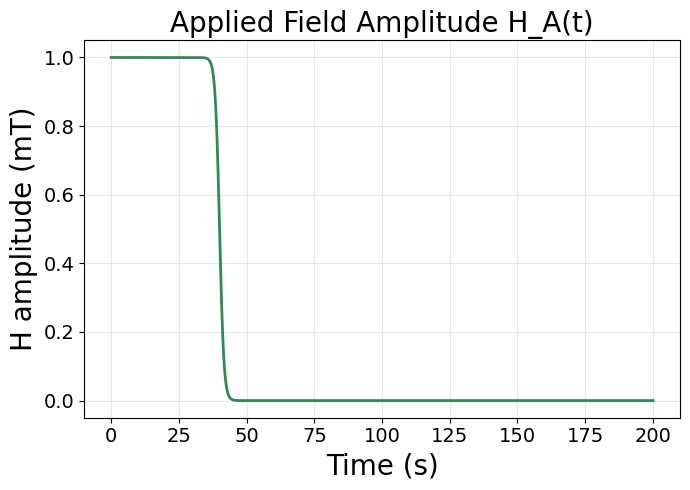

In [ ]:
# ================================================================
#  PLOT
# ================================================================
sl = slice(None)
# ---- H(t) ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], H_array[sl] * 1e3, color='seagreen', linewidth=2)
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('H amplitude (mT)', fontsize=20)
plt.title('Applied Field Amplitude H_A(t)', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()

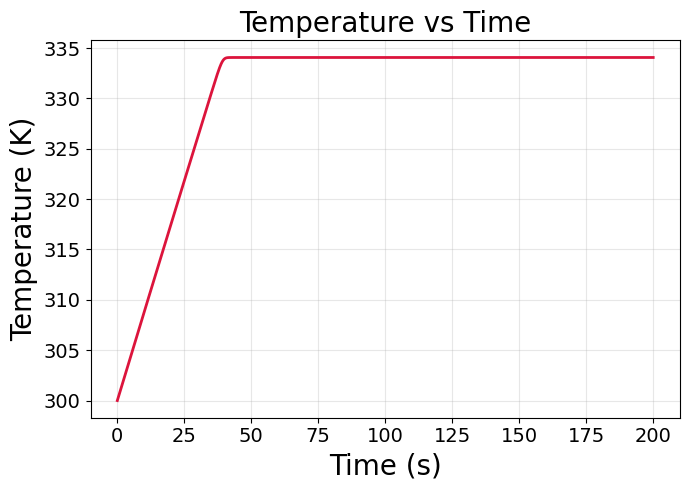

อุณหภูมิสุดท้ายที่ t = 200.00 s: 334.0649 K


In [ ]:
# ---- Temperature vs Time ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], Temp_array[sl], color='crimson', linewidth=2)
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('Temperature (K)', fontsize=20)
plt.title('Temperature vs Time', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()
print(f"อุณหภูมิสุดท้ายที่ t = {time_array[last_i]:.2f} s: {Temp_array[last_i]:.4f} K")

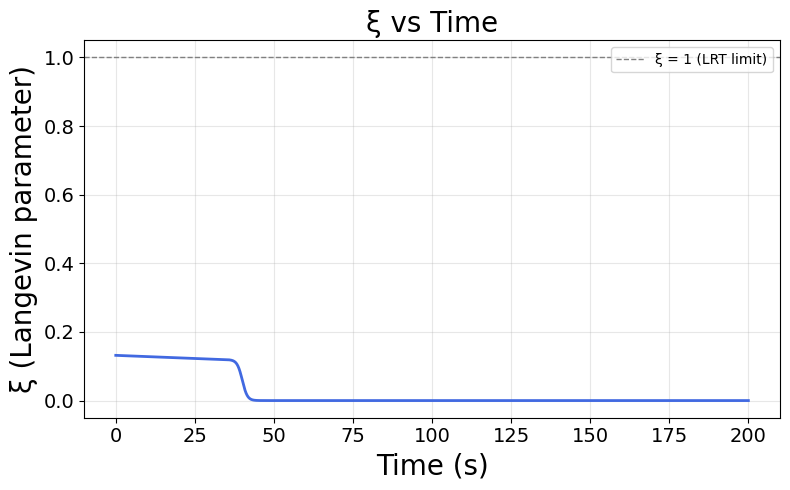

In [ ]:
# ---- xi vs Time ----
plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], xi_array[sl], color='royalblue', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='ξ = 1 (LRT limit)')
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('ξ (Langevin parameter)', fontsize=20)
plt.title('ξ vs Time', fontsize=20)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()